### **1. Import des bibliothèques**

In [14]:
# Numpy pour le calcul numérique
import numpy as np

# Matplotlib pour les graphiques
import matplotlib.pyplot as plt

# CIFAR-10 depuis keras
from tensorflow.keras.datasets import cifar10

# Classifieur KNN de sklearn
from sklearn.neighbors import KNeighborsClassifier

# Cross-validation 5 folds
from sklearn.model_selection import KFold

# Standardisation des données
from sklearn.preprocessing import StandardScaler


### **2. Chargement du dataset CIFAR-10**

In [15]:
# Chargement des données CIFAR-10
(X_train, y_train), (X_test, y_test) = cifar10.load_data()


### **3. Prétraitement des données**

In [16]:
# Fusion train et test pour la cross-validation
X = np.concatenate((X_train, X_test), axis=0)
y = np.concatenate((y_train, y_test), axis=0)


In [17]:
# Aplatir chaque image 32x32x3 → vecteur 3072
X = X.reshape(X.shape[0], -1)


In [18]:
# Standardisation (important pour KNN)
scaler = StandardScaler()
X = scaler.fit_transform(X)


### **4. Définition des valeurs de K**

In [19]:
# Valeurs de K à tester (comme dans la figure)
k_values = [1, 3, 5, 10, 20, 50, 100]


### **5. Cross-validation 5-folds**

In [20]:
# Création de la validation croisée à 5 folds
kf = KFold(n_splits=5, shuffle=True, random_state=42)


In [22]:
# Listes pour stocker les résultats
mean_accuracies = []
std_accuracies = []


### **N°6 — KNN + 5-Fold Cross-Validation**

**6.1 — Réduction du dataset**

In [27]:
# Réduction du dataset pour accélérer KNN
n_samples = 3000
X = X[:n_samples]
y = y[:n_samples]


**6.2 — Valeurs de K à tester**

In [28]:
# Valeurs de K
k_values = [1, 3, 5, 10, 20]


**6.3 — Initialisation du 5-Fold Cross-Validation**

In [29]:
from sklearn.model_selection import KFold

# Cross-validation 5 folds
kf = KFold(n_splits=5, shuffle=True, random_state=42)


**6.4 — Boucle KNN + Cross-Validation**

In [30]:
from sklearn.neighbors import KNeighborsClassifier
import numpy as np

mean_accuracies = []
std_accuracies = []

for k in k_values:
    accuracies = []  # accuracies pour chaque fold

    # Initialisation du classifieur KNN
    knn = KNeighborsClassifier(n_neighbors=k)

    # Boucle cross-validation
    for train_index, val_index in kf.split(X):
        # Séparation train / validation
        X_train_cv, X_val_cv = X[train_index], X[val_index]
        y_train_cv, y_val_cv = y[train_index], y[val_index]

        # Entraînement
        knn.fit(X_train_cv, y_train_cv.ravel())

        # Évaluation
        acc = knn.score(X_val_cv, y_val_cv)
        accuracies.append(acc)

    # Moyenne et écart-type
    mean_accuracies.append(np.mean(accuracies))
    std_accuracies.append(np.std(accuracies))


**6.5 — Vérification des résultats**

In [31]:
print("Accuracy moyenne :", mean_accuracies)
print("Écart-type :", std_accuracies)


Accuracy moyenne : [np.float64(0.256), np.float64(0.24500000000000002), np.float64(0.25433333333333336), np.float64(0.2643333333333333), np.float64(0.26733333333333337)]
Écart-type : [np.float64(0.013848385385227334), np.float64(0.02412928142780514), np.float64(0.02075250988836451), np.float64(0.01515109090315134), np.float64(0.014742229591663982)]


### **N°7 — Tracé de la courbe Accuracy vs K**

**7.1 — Sécurité (conversion en numpy)**

In [32]:
import numpy as np

mean_accuracies = np.array(mean_accuracies)
std_accuracies  = np.array(std_accuracies)


**Cellule 7.2 — Tracé de la courbe**

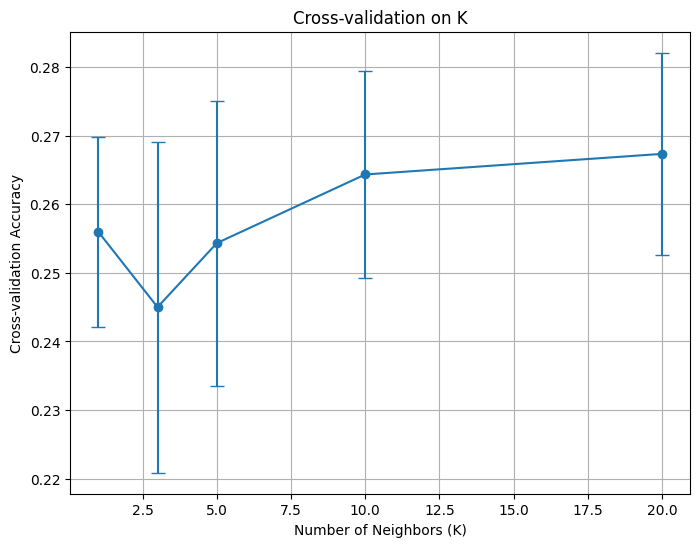

In [33]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

# Courbe avec barres d'erreur (écart-type)
plt.errorbar(
    k_values,
    mean_accuracies,
    yerr=std_accuracies,
    fmt='o-',
    capsize=5
)

# Titres et labels (exactement comme demandé)
plt.title("Cross-validation on K")
plt.xlabel("Number of Neighbors (K)")
plt.ylabel("Cross-validation Accuracy")

# Grille
plt.grid(True)

# Affichage
plt.show()
